# 🏦 Bank Marketing Prediction using Machine Learning

---

## 📖 Project Overview

This project aims to predict whether a customer will subscribe to a bank term deposit based on demographic, financial, and previous marketing campaign information.

The notebook follows a complete Machine Learning pipeline including data cleaning, exploratory data analysis, feature engineering, preprocessing, model building, hyperparameter tuning, model comparison, explainability, and prediction for new customers.

---

## 🎯 Business Problem

Banks spend a large amount of money contacting customers through phone marketing campaigns.

Predicting customers who are likely to subscribe allows the bank to:

- Reduce marketing costs.
- Increase campaign success.
- Improve customer targeting.
- Save employees' time.

---

## 🎯 Project Objective

The objectives of this project are:

✔ Understand the dataset

✔ Clean the data

✔ Perform Exploratory Data Analysis (EDA)

✔ Engineer useful features

✔ Handle Imbalanced Data

✔ Train multiple Machine Learning models

✔ Optimize each model

✔ Compare model performance

✔ Explain predictions

✔ Predict new customer subscriptions

---

## 📊 Machine Learning Type

Classification Problem

Target Variable

deposit

Classes

• Yes

• No

| Feature   | Description                        |
| --------- | ---------------------------------- |
| age       | Customer Age                       |
| job       | Occupation                         |
| marital   | Marital Status                     |
| education | Education Level                    |
| default   | Has Credit in Default              |
| balance   | Average Yearly Balance             |
| housing   | Housing Loan                       |
| loan      | Personal Loan                      |
| contact   | Contact Communication Type         |
| day       | Last Contact Day                   |
| month     | Last Contact Month                 |
| duration  | Last Contact Duration              |
| campaign  | Number of Contacts During Campaign |
| pdays     | Days Passed Since Previous Contact |
| previous  | Previous Contacts                  |
| poutcome  | Previous Campaign Outcome          |
| deposit   | Target Variable                    |


In [86]:
# ===========================
# 1. Import Libraries
# ===========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler
)

# Train Test Split
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# XGBoost
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier

# CatBoost
#from catboost import CatBoostClassifier

# Feature Selection
from sklearn.feature_selection import SelectFromModel

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from scipy.stats import randint
from sklearn.model_selection import cross_val_score
import time

In [87]:
df = pd.read_csv("/content/bank.csv")

In [88]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343.0,yes,no,unknown,5.0,may,1042.0,1.0,-1.0,0.0,unknown,yes
1,56,admin.,married,secondary,no,45.0,no,no,unknown,5.0,may,1467.0,1.0,-1.0,0.0,unknown,yes
2,41,technician,married,secondary,no,1270.0,yes,no,unknown,5.0,may,1389.0,1.0,-1.0,0.0,unknown,yes
3,54,admin.,married,tertiary,no,184.0,no,no,unknown,5.0,may,673.0,2.0,-1.0,0.0,unknown,yes
4,42,management,single,tertiary,no,0.0,yes,yes,unknown,5.0,may,562.0,2.0,-1.0,0.0,unknown,yes


In [89]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
8907,33,blue-collar,single,primary,no,1.0,yes,no,cellular,20.0,apr,257.0,1.0,-1.0,0.0,unknown,no
8908,39,services,married,secondary,no,733.0,no,no,unknown,16.0,jun,83.0,4.0,-1.0,0.0,unknown,no
8909,32,technician,single,secondary,no,29.0,no,no,cellular,19.0,aug,156.0,2.0,-1.0,0.0,unknown,no
8910,43,technician,married,secondary,no,0.0,no,yes,cellular,8.0,may,9.0,2.0,172.0,5.0,failure,no
8911,34,technician,married,secondary,no,0.0,no,no,cellular,9.0,jul,628.0,1.0,-1.0,0.0,unknown,no


In [90]:
df.sample(5, random_state=42)# بياخد خمسه سامبل عشواءي

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
3106,28,management,single,tertiary,no,1584.0,yes,no,cellular,1.0,sep,222.0,2.0,-1.0,0.0,unknown,yes
1488,39,admin.,single,secondary,no,2345.0,yes,no,cellular,8.0,may,491.0,2.0,344.0,2.0,failure,yes
2272,51,self-employed,single,secondary,no,0.0,no,no,cellular,29.0,oct,1707.0,2.0,-1.0,0.0,unknown,yes
7336,29,technician,single,secondary,no,544.0,yes,no,unknown,13.0,may,360.0,1.0,-1.0,0.0,unknown,no
8819,34,management,single,tertiary,yes,621.0,no,no,cellular,28.0,aug,205.0,3.0,-1.0,0.0,unknown,no


In [91]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 8912
Columns : 17


In [92]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8912 entries, 0 to 8911
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        8912 non-null   int64  
 1   job        8905 non-null   object 
 2   marital    8743 non-null   object 
 3   education  8885 non-null   object 
 4   default    8908 non-null   object 
 5   balance    8899 non-null   float64
 6   housing    8899 non-null   object 
 7   loan       8882 non-null   object 
 8   contact    8881 non-null   object 
 9   day        8893 non-null   float64
 10  month      8884 non-null   object 
 11  duration   8905 non-null   float64
 12  campaign   8904 non-null   float64
 13  pdays      8767 non-null   float64
 14  previous   8909 non-null   float64
 15  poutcome   8912 non-null   object 
 16  deposit    8903 non-null   object 
dtypes: float64(6), int64(1), object(10)
memory usage: 1.2+ MB


In [94]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,8912.0,41.257855,11.840567,18.0,32.0,39.0,49.0,95.0
balance,8899.0,1539.680638,3297.446702,-3058.0,121.5,553.0,1726.0,81204.0
day,8893.0,15.684921,8.406729,1.0,8.0,15.0,22.0,31.0
duration,8905.0,374.953734,351.283501,3.0,139.0,256.0,501.0,3284.0
campaign,8904.0,2.512579,2.772366,1.0,1.0,2.0,3.0,63.0
pdays,8767.0,52.456941,109.094161,-1.0,-1.0,-1.0,64.0,842.0
previous,8909.0,0.834325,2.304733,0.0,0.0,0.0,1.0,58.0


In [95]:
df.describe(include='object').T

,count,unique,top,freq
job,8905,12,management,2078
marital,8743,3,married,4980
education,8885,4,secondary,4364
default,8908,2,no,8762
housing,8899,2,no,4657
loan,8882,2,no,7703
contact,8881,3,cellular,6381
month,8884,12,may,2265
poutcome,8912,4,unknown,6638
deposit,8903,2,no,4673


In [96]:
missing = pd.DataFrame({

    "Missing Values":df.isnull().sum(),

    "Percentage":round(df.isnull().mean()*100,2)

})

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
marital,169,1.90
pdays,145,1.63
contact,31,0.35
loan,30,0.34
month,28,0.31
education,27,0.30
day,19,0.21
balance,13,0.15
housing,13,0.15
deposit,9,0.10


In [97]:
duplicates=df.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


In [98]:
unique = pd.DataFrame({

    "Unique Values":df.nunique(),

    "Data Type":df.dtypes

})

unique

,Unique Values,Data Type
age,76,int64
job,12,object
marital,3,object
education,4,object
default,2,object
balance,3435,float64
housing,2,object
loan,2,object
contact,3,object
day,31,float64


## Data Quality **Report**

In [99]:
quality = pd.DataFrame({

"Data Type":df.dtypes,

"Missing":df.isnull().sum(),

"Missing %":round(df.isnull().mean()*100,2),

"Unique":df.nunique()

})

quality

,Data Type,Missing,Missing %,Unique
age,int64,0,0.00,76
job,object,7,0.08,12
marital,object,169,1.90,3
education,object,27,0.30,4
default,object,4,0.04,2
balance,float64,13,0.15,3435
housing,object,13,0.15,2
loan,object,30,0.34,2
contact,object,31,0.35,3
day,float64,19,0.21,31


In [100]:
df["deposit"].value_counts()

,count
deposit,
no,4673
yes,4230


In [101]:
round(df["deposit"].value_counts(normalize=True)*100,2)

,proportion
deposit,
no,52.49
yes,47.51


In [102]:
print(f"""

Dataset Shape : {df.shape}

Missing Values : {df.isnull().sum().sum()}

Duplicate Rows : {df.duplicated().sum()}

Target Classes :

{df.deposit.value_counts()}

""")



Dataset Shape : (8912, 17)

Missing Values : 513

Duplicate Rows : 0

Target Classes :

deposit
no     4673
yes    4230
Name: count, dtype: int64




# Dashboard 1 : Data Overview


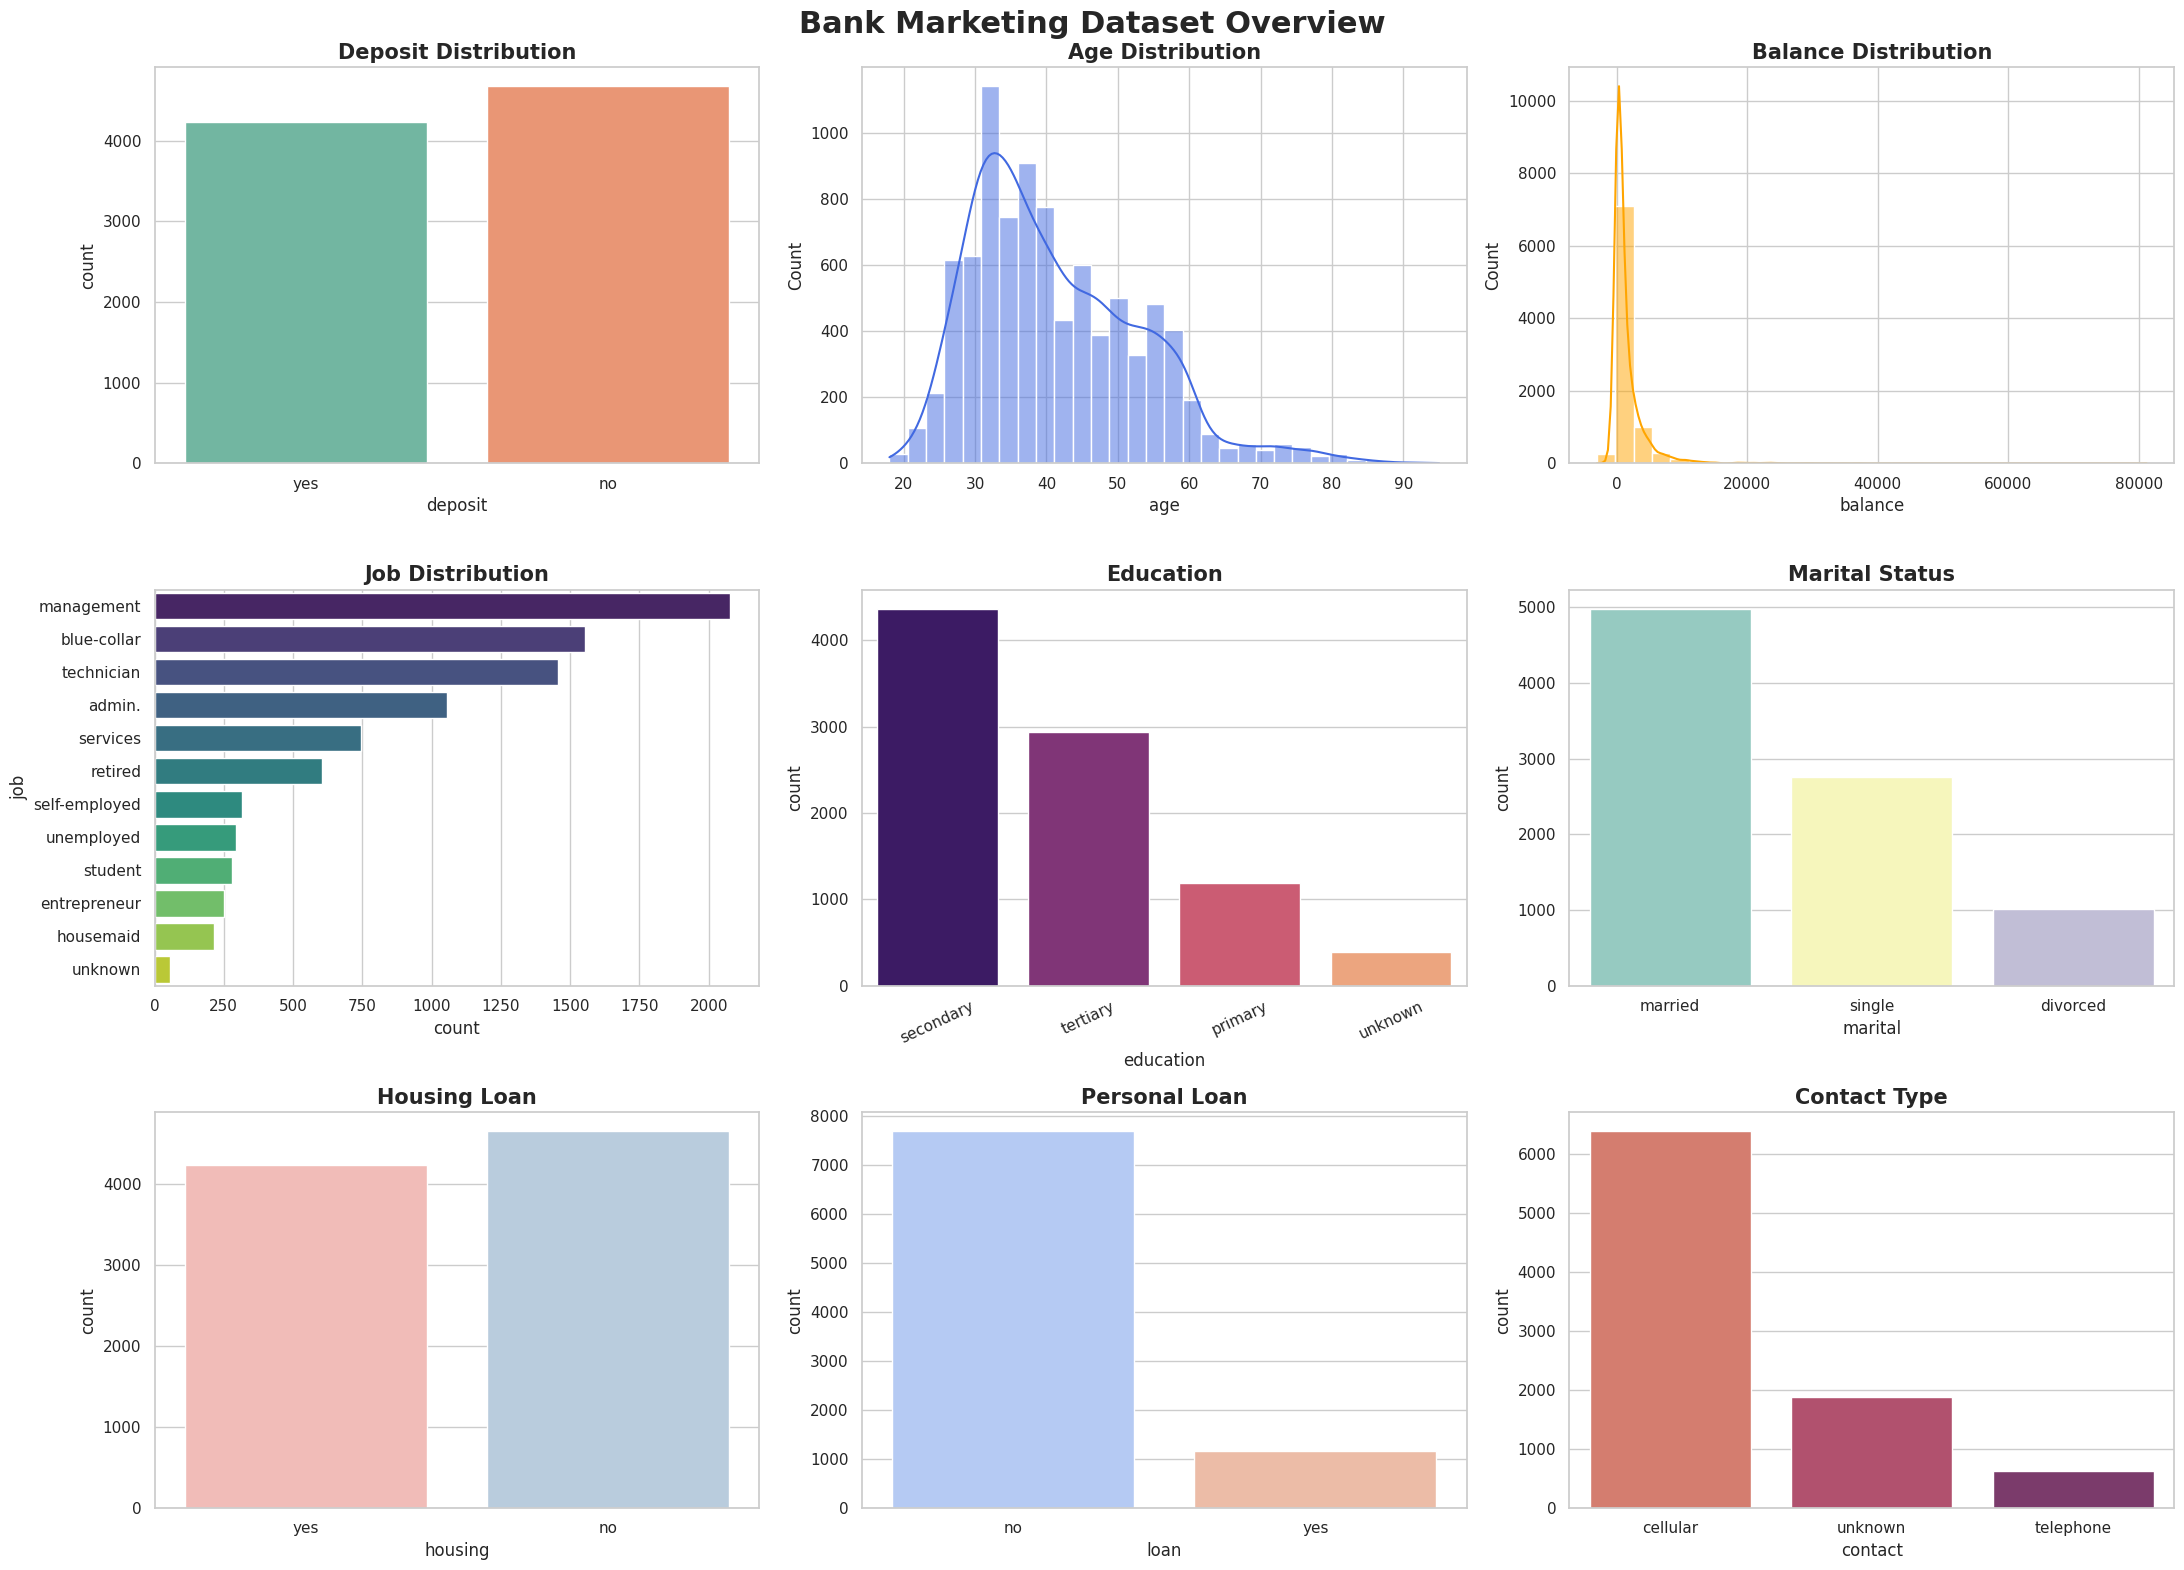

In [103]:
# ===============================
# Dashboard 1 : Data Overview
# ===============================

fig, ax = plt.subplots(3, 3, figsize=(22, 16))

# 1- Target
sns.countplot(
    data=df,
    x='deposit',
    palette='Set2',
    ax=ax[0,0]
)
ax[0,0].set_title("Deposit Distribution",fontsize=15,fontweight='bold')

# 2- Age
sns.histplot(
    data=df,
    x='age',
    bins=30,
    kde=True,
    color='royalblue',
    ax=ax[0,1]
)
ax[0,1].set_title("Age Distribution",fontsize=15,fontweight='bold')

# 3- Balance
sns.histplot(
    data=df,
    x='balance',
    bins=30,
    kde=True,
    color='orange',
    ax=ax[0,2]
)
ax[0,2].set_title("Balance Distribution",fontsize=15,fontweight='bold')

# 4- Job
sns.countplot(
    data=df,
    y='job',
    palette='viridis',
    order=df['job'].value_counts().index,
    ax=ax[1,0]
)
ax[1,0].set_title("Job Distribution",fontsize=15,fontweight='bold')

# 5- Education
sns.countplot(
    data=df,
    x='education',
    palette='magma',
    order=df['education'].value_counts().index,
    ax=ax[1,1]
)
ax[1,1].tick_params(axis='x',rotation=25)
ax[1,1].set_title("Education",fontsize=15,fontweight='bold')

# 6- Marital
sns.countplot(
    data=df,
    x='marital',
    palette='Set3',
    order=df['marital'].value_counts().index,
    ax=ax[1,2]
)
ax[1,2].set_title("Marital Status",fontsize=15,fontweight='bold')

# 7- Housing Loan
sns.countplot(
    data=df,
    x='housing',
    palette='Pastel1',
    ax=ax[2,0]
)
ax[2,0].set_title("Housing Loan",fontsize=15,fontweight='bold')

# 8- Personal Loan
sns.countplot(
    data=df,
    x='loan',
    palette='coolwarm',
    ax=ax[2,1]
)
ax[2,1].set_title("Personal Loan",fontsize=15,fontweight='bold')

# 9- Contact Type
sns.countplot(
    data=df,
    x='contact',
    palette='flare',
    order=df['contact'].value_counts().index,
    ax=ax[2,2]
)
ax[2,2].set_title("Contact Type",fontsize=15,fontweight='bold')

plt.suptitle(
    "Bank Marketing Dataset Overview",
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

# Dashboard 2 : Numerical Analysis


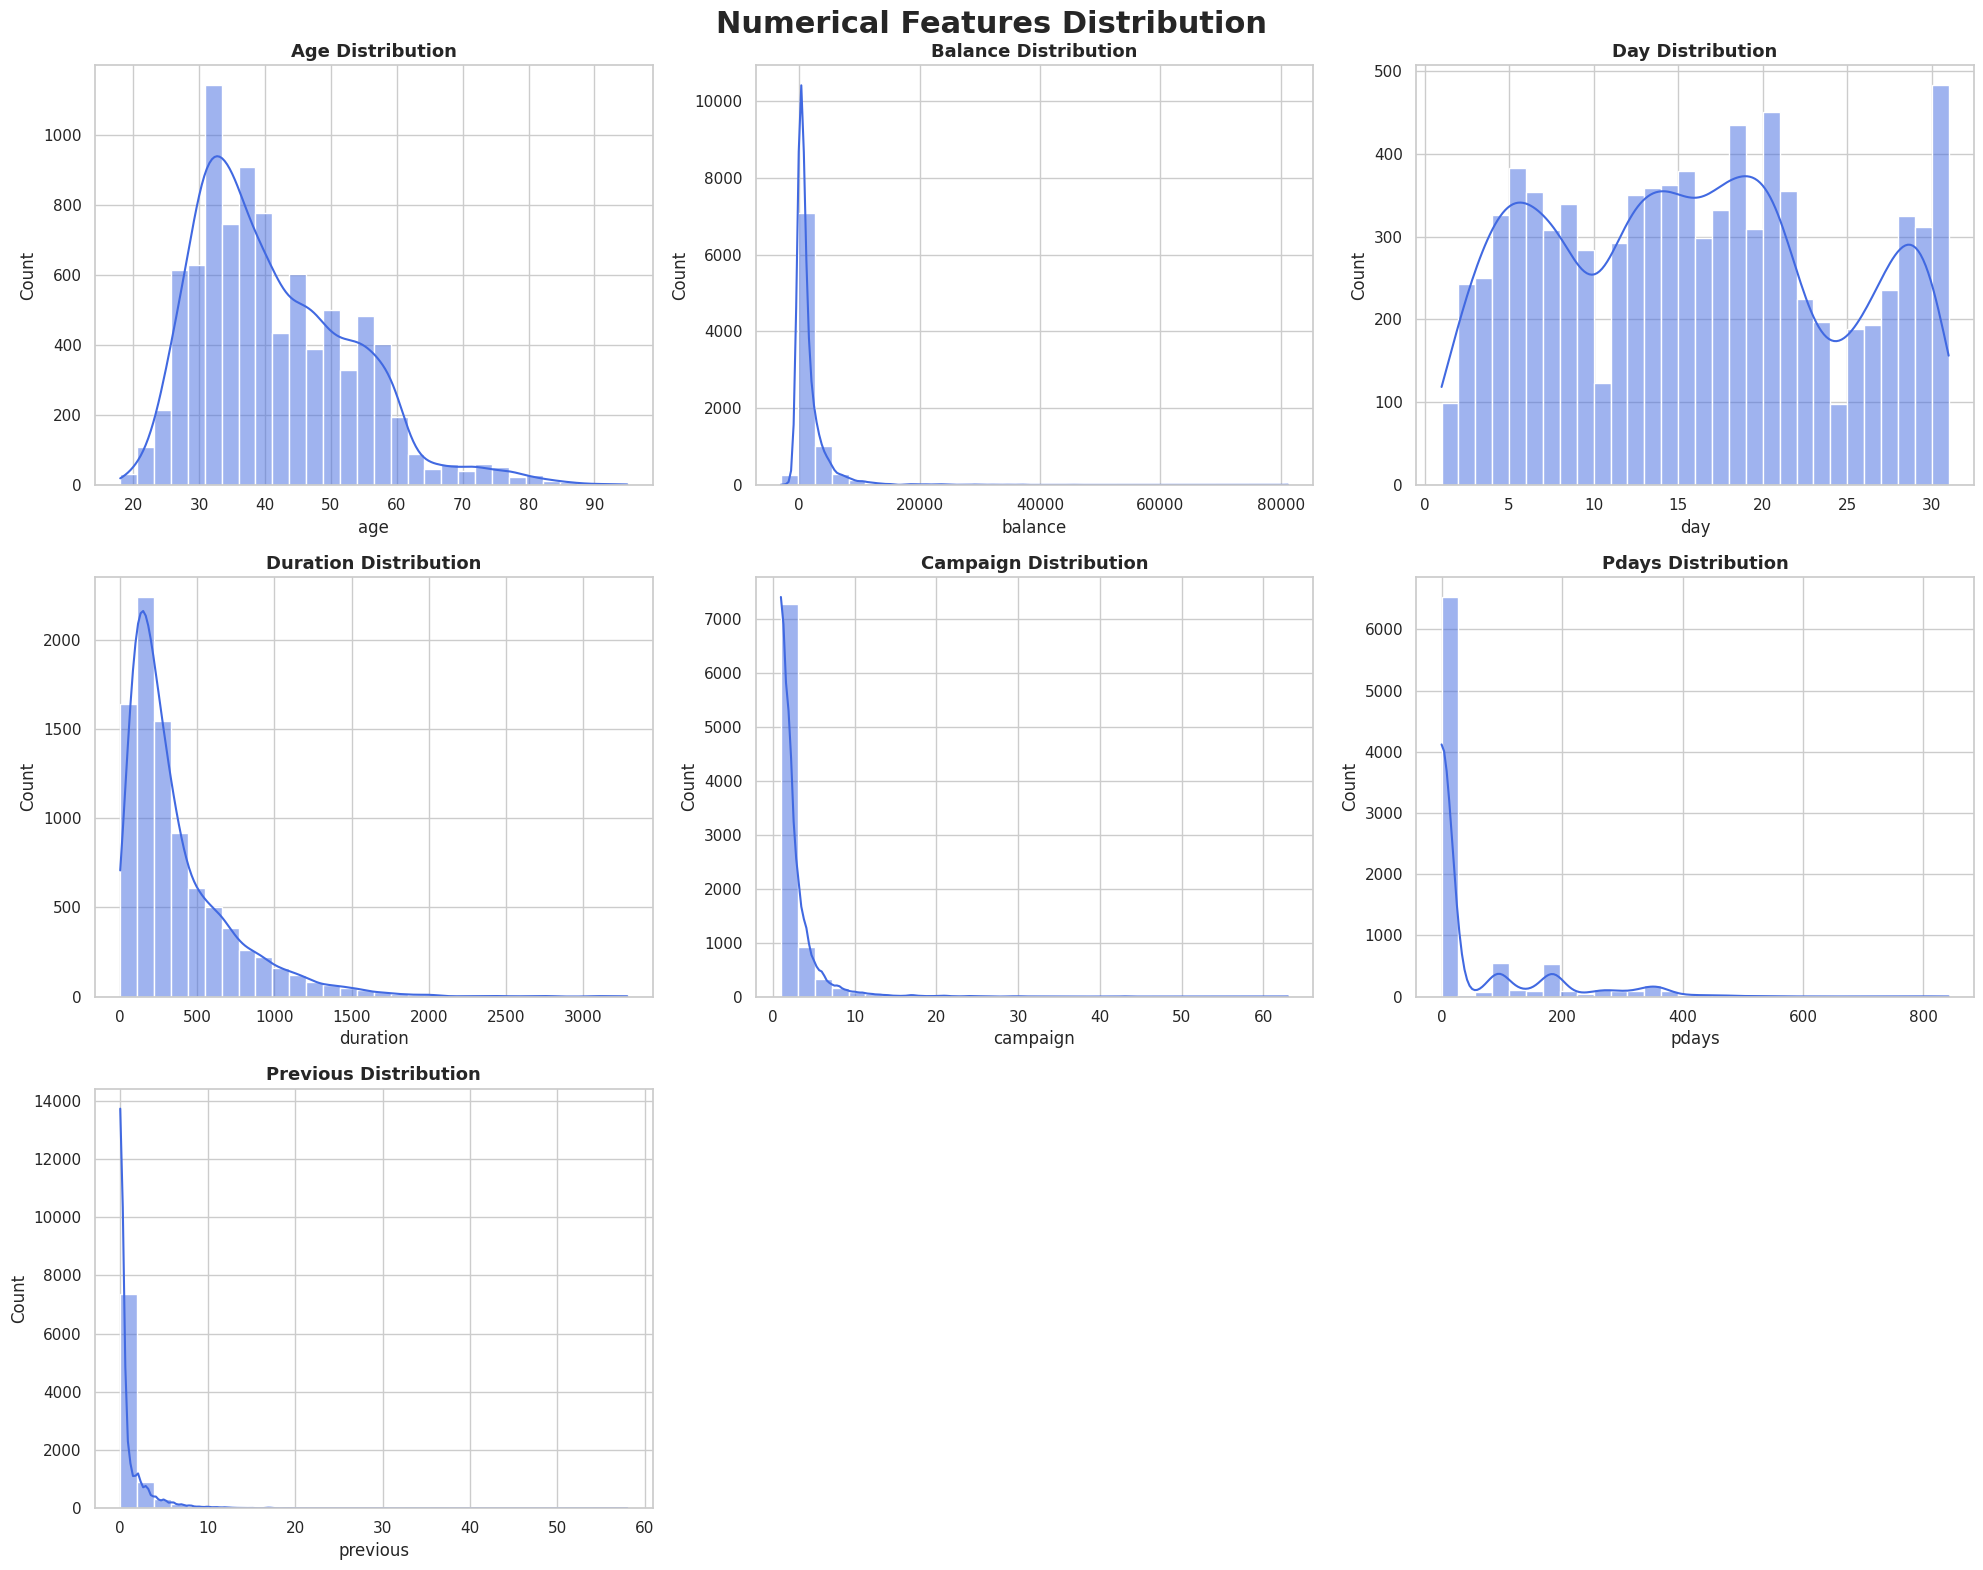

In [104]:
# ============================================
# Dashboard 3 : Numerical Features Distribution
# ============================================

num_cols = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        color='royalblue',
        ax=axes[i]
    )

    axes[i].set_title(
        f'{col.capitalize()} Distribution',
        fontsize=13,
        fontweight='bold'
    )

# حذف المحاور الفارغة
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Numerical Features Distribution",
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

Relationship with Deposit (Numerical)

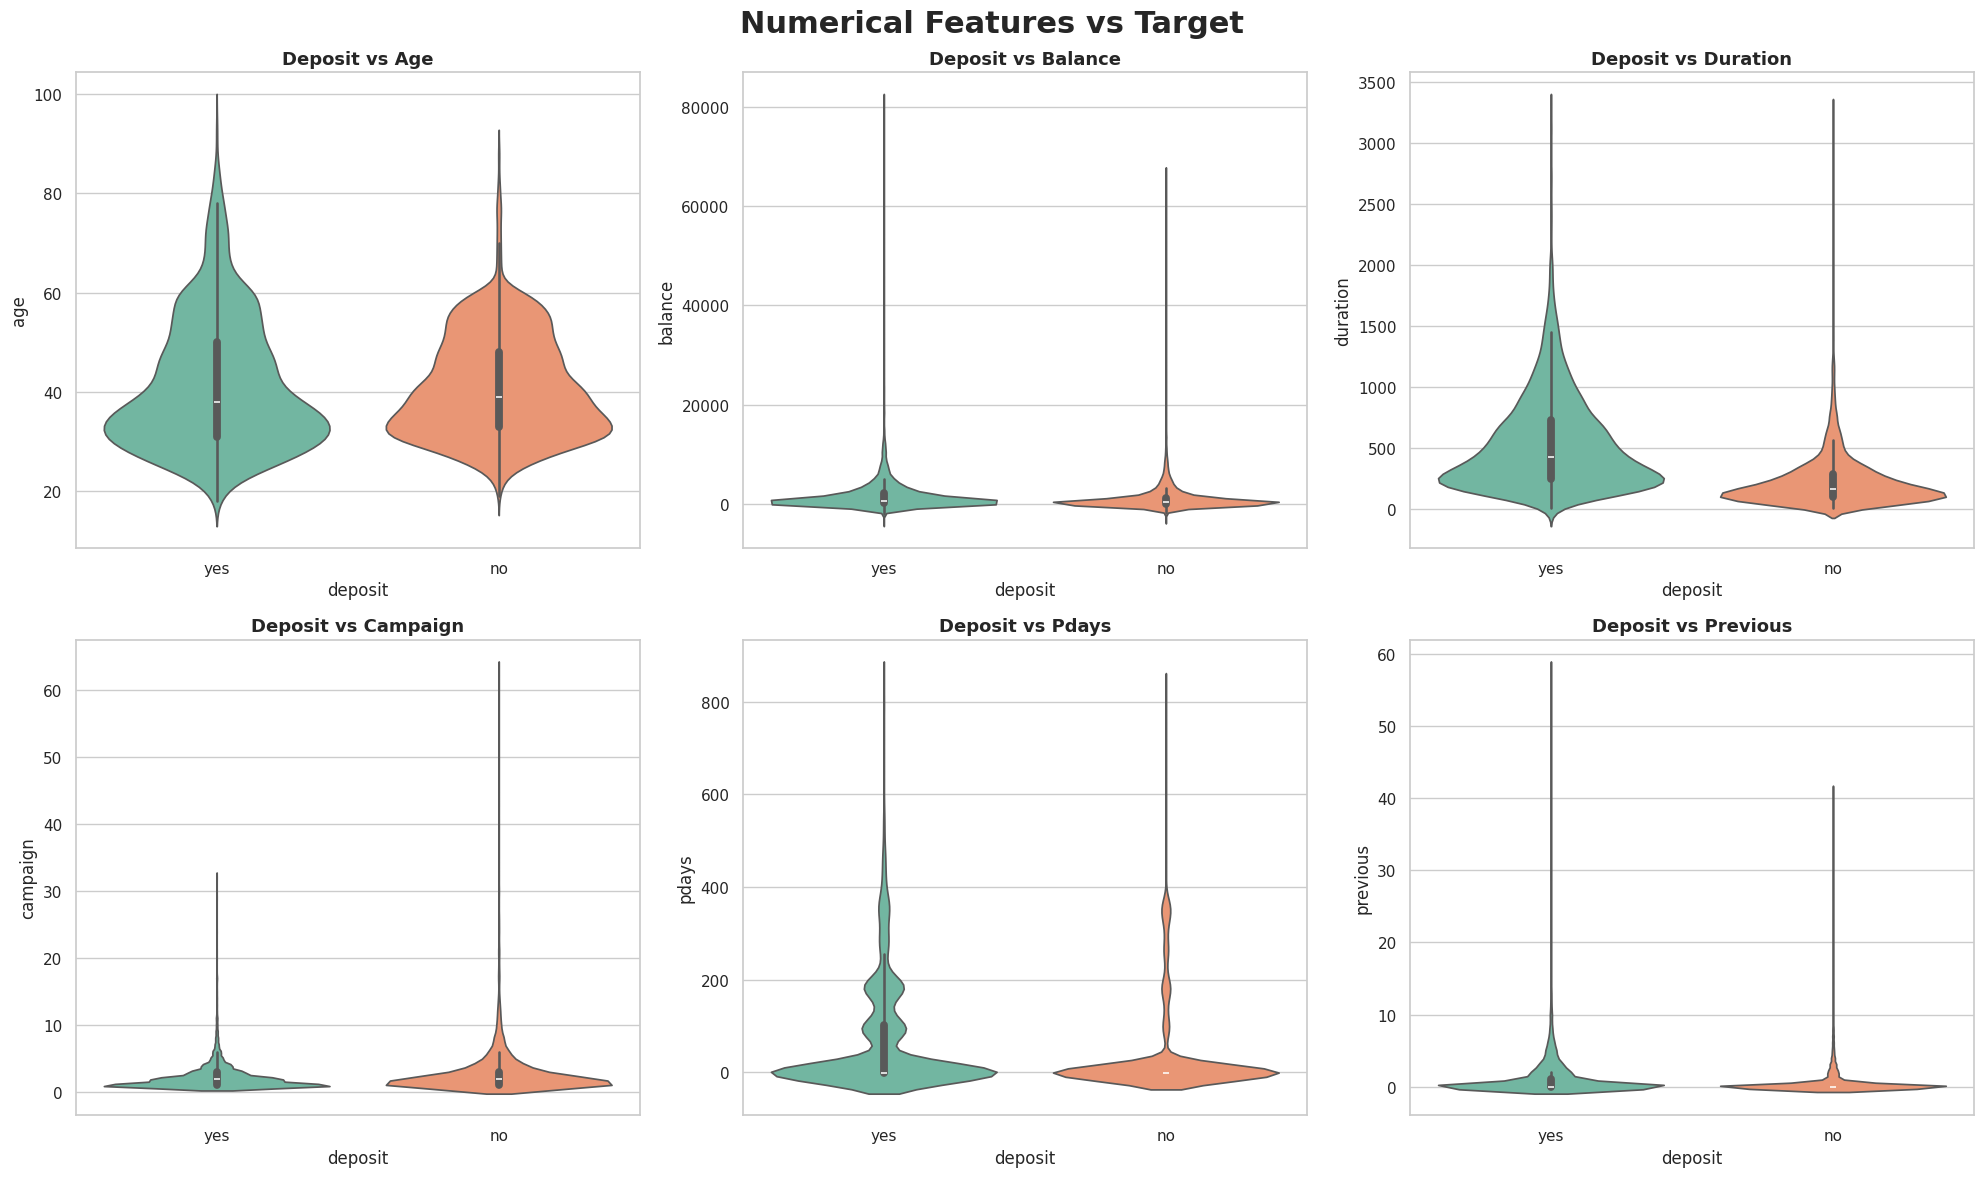

In [105]:
# ============================================
# Dashboard 5 : Numerical Features vs Deposit
# ============================================

fig, axes = plt.subplots(2,3, figsize=(20,12))
axes = axes.flatten()

features = [
    'age',
    'balance',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

for i, col in enumerate(features):

    sns.violinplot(
        data=df,
        x='deposit',
        y=col,
        palette='Set2',
        ax=axes[i]
    )

    axes[i].set_title(
        f'Deposit vs {col.capitalize()}',
        fontsize=13,
        fontweight='bold'
    )

plt.suptitle(
    "Numerical Features vs Target",
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

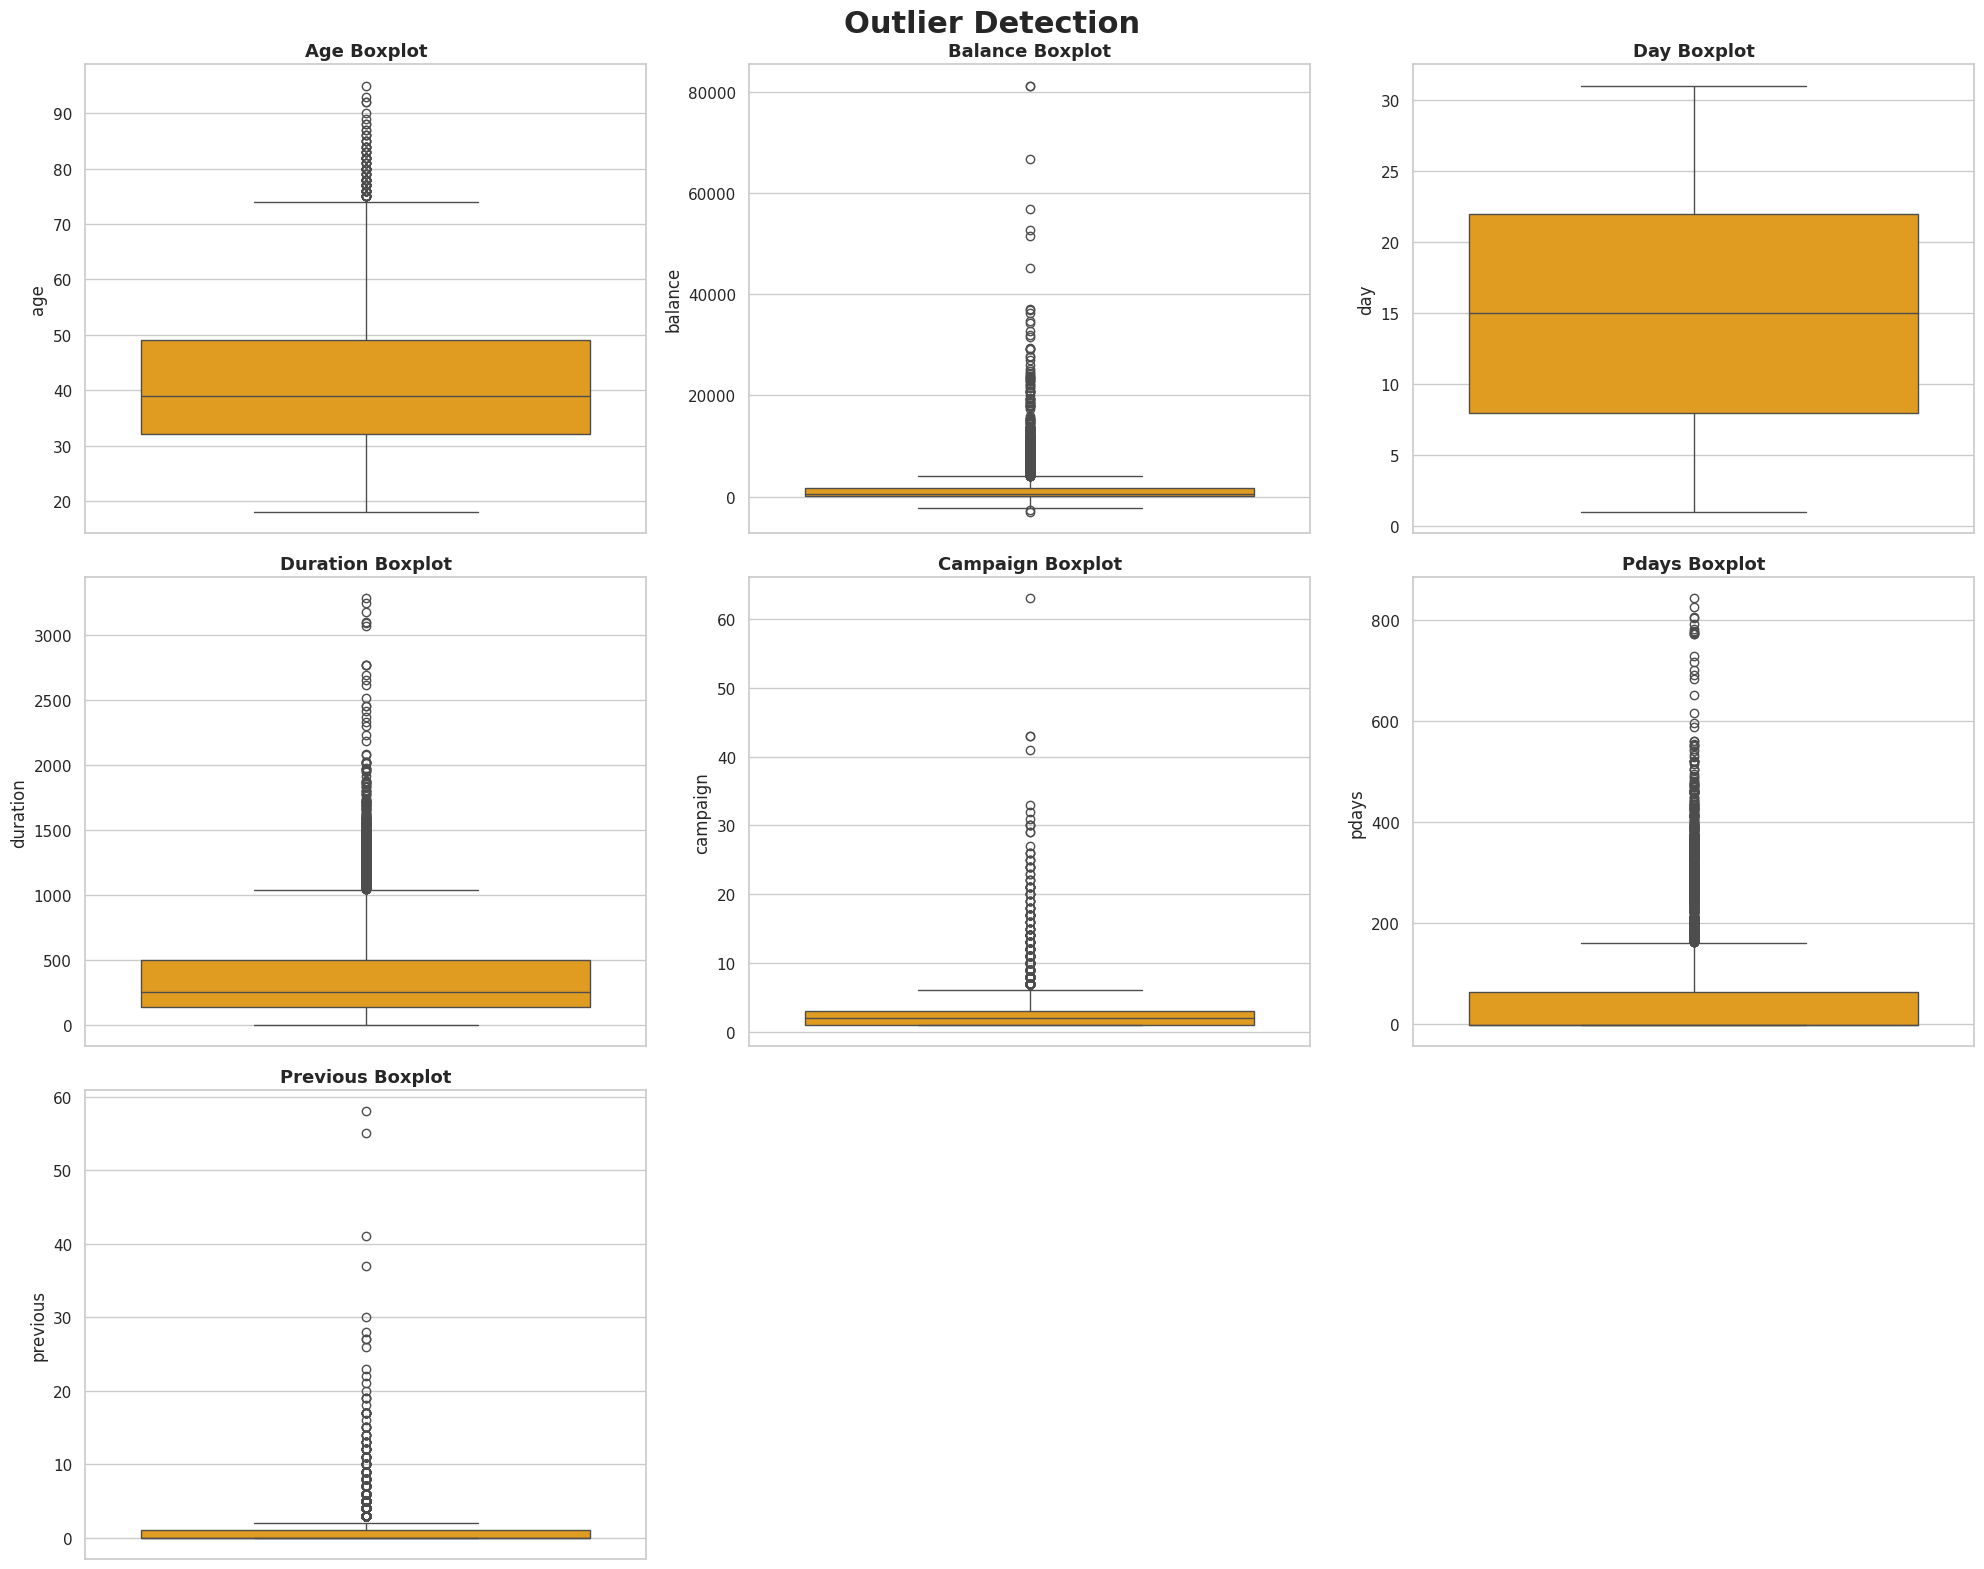

In [106]:
# ============================================
# Dashboard 4 : Outlier Detection
# ============================================

fig, axes = plt.subplots(3, 3, figsize=(20,16))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.boxplot(
        y=df[col],
        color='orange',
        ax=axes[i]
    )

    axes[i].set_title(
        f'{col.capitalize()} Boxplot',
        fontsize=13,
        fontweight='bold'
    )

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Outlier Detection",
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

## Handle Missing **Values**

In [107]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_imputer = SimpleImputer(strategy="median")

df[numeric_columns] = numeric_imputer.fit_transform(df[numeric_columns])

In [108]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_imputer = SimpleImputer(strategy="most_frequent")

df[categorical_columns] = categorical_imputer.fit_transform(df[categorical_columns])

In [109]:
df.isnull().sum().sum()

np.int64(0)

In [110]:
for col in categorical_columns:
    print(col," -----> ",df[col].nunique())

job  ----->  12
marital  ----->  3
education  ----->  4
default  ----->  2
housing  ----->  2
loan  ----->  2
contact  ----->  3
month  ----->  12
poutcome  ----->  4
deposit  ----->  2


# encoding

In [111]:
binary_cols = [
    "default",
    "housing",
    "loan",
    "deposit"
]

In [112]:
low_cardinality = [
    "marital",
    "education",
    "contact",
    "poutcome"
]

In [113]:
high_cardinality = [
    "job",
    "month"
]

In [114]:
# ===========================
# Binary Encoding
# ===========================

binary_cols = [
    "default",
    "housing",
    "loan",
    "deposit"
]

for col in binary_cols:
    df[col] = df[col].map({
        "yes":1,
        "no":0
    })

In [115]:
# ===========================
# Frequency Encoding
# ===========================

freq_cols = [
    "job",
    "month"
]

for col in freq_cols:

    frequency = df[col].value_counts(normalize=True)

    df[col] = df[col].map(frequency)

In [116]:
# ===========================
# One Hot Encoding
# ===========================

onehot_cols = [
    "marital",
    "education",
    "contact",
    "poutcome"
]

df = pd.get_dummies(
    df,
    columns=onehot_cols,
    drop_first=True,
    dtype=int
)

In [117]:
df.head()

,age,job,default,balance,housing,loan,day,month,duration,campaign,...,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,59.0,0.118492,0,2343.0,1,0,5.0,0.257294,1042.0,1.0,...,1,0,1,0,0,0,1,0,0,1
1,56.0,0.118492,0,45.0,0,0,5.0,0.257294,1467.0,1.0,...,1,0,1,0,0,0,1,0,0,1
2,41.0,0.163600,0,1270.0,1,0,5.0,0.257294,1389.0,1.0,...,1,0,1,0,0,0,1,0,0,1
3,54.0,0.118492,0,184.0,0,0,5.0,0.257294,673.0,2.0,...,1,0,0,1,0,0,1,0,0,1
4,42.0,0.233954,0,0.0,1,1,5.0,0.257294,562.0,2.0,...,0,1,0,1,0,0,1,0,0,1


 Split

In [118]:
# ===========================
# Split X & y
# ===========================

X = df.drop("deposit",axis=1)

y = df["deposit"]

print(X.shape)
print(y.shape)

(8912, 22)
(8912,)


In [119]:
# ===========================
# Train Test Split
# ===========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7129, 22)
(1783, 22)


In [120]:
# ===========================
# Scaling
# ===========================

scale_cols = [
    col for col in X_train.columns
    if X_train[col].nunique() > 2
]

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])

X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [121]:
X_train.head()

,age,job,default,balance,housing,loan,day,month,duration,campaign,...,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
6720,-0.785924,1.298310,0,-0.448464,0,0,0.747350,-0.013321,-0.434099,1.258511,...,1,0,0,1,0,0,0,0,0,1
5845,-0.107202,0.298594,0,-0.431382,0,0,1.461588,-0.013321,0.966358,1.981674,...,1,0,0,1,0,0,0,0,0,1
4222,-0.785924,-0.342372,0,-0.372481,1,0,1.580628,-0.691151,0.972039,0.173766,...,1,0,0,1,0,0,0,0,0,1
7394,-0.192042,-1.935220,0,-0.456121,0,0,1.461588,-1.340380,-0.985192,-0.549397,...,0,1,0,0,1,1,0,0,0,1
943,-0.107202,1.298310,0,-0.070907,0,0,-1.514404,-0.854173,3.980323,-0.187815,...,1,0,0,1,0,1,0,0,0,1


In [122]:
# ===========================================
# Classification Models
# ===========================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Gaussian NB": GaussianNB(),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    )
}

In [123]:
def evaluate_model(model, model_name):

    start = time.time()

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:,1]
    else:
        prob = model.decision_function(X_test)

    cv = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    ).mean()

    end = time.time()

    results.append({

        "Model":model_name,

        "Train Accuracy":train_acc,

        "Test Accuracy":test_acc,

        "CV Score":cv,

        "Precision":precision_score(y_test,test_pred),

        "Recall":recall_score(y_test,test_pred),

        "F1":f1_score(y_test,test_pred),

        "ROC AUC":roc_auc_score(y_test,prob),

        "Time":round(end-start,2)

    })

    return model

In [125]:
# ===========================================
# Train All Models
# ===========================================

results = []

trained_models = {}

for name, model in models.items():

    trained_model = evaluate_model(model, name)

    trained_models[name] = trained_model

In [126]:
comparison = pd.DataFrame(results)

comparison.sort_values(
    "Test Accuracy",
    ascending=False,
    inplace=True
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,Train Accuracy,Test Accuracy,CV Score,Precision,Recall,F1,ROC AUC,Time
0,LightGBM,0.922149,0.860348,0.858324,0.824104,0.897163,0.859083,0.916912,9.25
1,XGBoost,0.971104,0.853057,0.853415,0.823725,0.878251,0.850114,0.913268,1.91
2,Random Forest,1.000000,0.851374,0.847944,0.810695,0.895981,0.851207,0.906507,4.93
3,Gradient Boosting,0.863515,0.841279,0.845279,0.802363,0.882979,0.840743,0.903814,5.84
4,Extra Trees,1.000000,0.827818,0.831253,0.803150,0.843972,0.823055,0.891597,3.82
5,SVM,0.849488,0.823892,0.822555,0.785408,0.865248,0.823397,0.893419,32.39
6,AdaBoost,0.810492,0.801458,0.806704,0.783410,0.803783,0.793466,0.880770,1.73
7,Logistic Regression,0.810352,0.800337,0.807826,0.795181,0.780142,0.787589,0.877215,3.51
8,KNN,0.855800,0.786315,0.789032,0.775801,0.773050,0.774423,0.852639,2.39
9,Decision Tree,1.000000,0.781268,0.785522,0.773381,0.762411,0.767857,0.780352,0.56


In [127]:
lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1
)

lgbm.fit(X_train,y_train)

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":lgbm.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
8,duration,587
7,month,429
3,balance,400
6,day,363
0,age,340
10,pdays,198
1,job,137
9,campaign,115
4,housing,70
18,contact_unknown,64


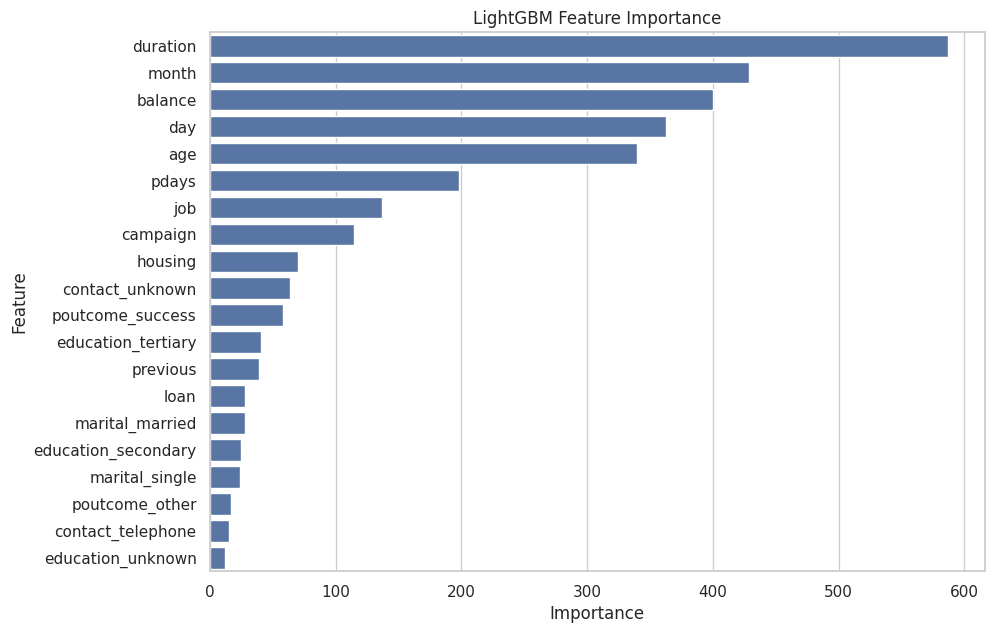

In [128]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("LightGBM Feature Importance")

plt.show()

In [129]:
scores = []

for top in [5,10,15,20,len(X_train.columns)]:

    cols = importance.head(top)["Feature"]

    model = LGBMClassifier(
        random_state=42,
        verbose=-1
    )

    model.fit(
        X_train[cols],
        y_train
    )

    pred = model.predict(
        X_test[cols]
    )

    scores.append({

        "Top Features":top,

        "Accuracy":accuracy_score(
            y_test,
            pred
        )

    })

scores = pd.DataFrame(scores)

scores

,Top Features,Accuracy
0,5,0.827257
1,10,0.859226
2,15,0.859787
3,20,0.860348
4,22,0.860348


In [130]:
best_top = int(
    scores.sort_values(
        "Accuracy",
        ascending=False
    ).iloc[0]["Top Features"]
)

selected_features = importance.head(best_top)["Feature"]

X_train_best = X_train[selected_features]

X_test_best = X_test[selected_features]

In [131]:
from scipy.stats import randint

params = {

    "num_leaves": randint(20,100),

    "learning_rate":[
        0.005,
        0.01,
        0.05,
        0.1
    ],

    "max_depth":[
        -1,
        5,
        10,
        15,
        20
    ],

    "n_estimators":[
        100,
        200,
        300,
        500,
        700
    ],

    "min_child_samples":[
        10,
        20,
        30,
        40
    ],

    "subsample":[
        0.7,
        0.8,
        0.9,
        1
    ],

    "colsample_bytree":[
        0.7,
        0.8,
        0.9,
        1
    ]
}

In [132]:
random_search = RandomizedSearchCV(

    estimator=LGBMClassifier(
        random_state=42,
        verbose=-1
    ),

    param_distributions=params,

    n_iter=40,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1

)

random_search.fit(
    X_train_best,
    y_train
)

print(random_search.best_score_)

print(random_search.best_params_)

0.8591649811766443
{'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 10, 'n_estimators': 500, 'num_leaves': 47, 'subsample': 1}


In [133]:
best = random_search.best_params_

grid = {

    "learning_rate":[
        best["learning_rate"]
    ],

    "num_leaves":[

        max(2,best["num_leaves"]-10),

        best["num_leaves"],

        best["num_leaves"]+10

    ],

    "n_estimators":[

        max(50,best["n_estimators"]-100),

        best["n_estimators"],

        best["n_estimators"]+100

    ],

    "max_depth":[

        best["max_depth"]

    ]
}

In [134]:
grid_search = GridSearchCV(

    estimator=LGBMClassifier(
        random_state=42,
        verbose=-1
    ),

    param_grid=grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(
    X_train_best,
    y_train
)

print(grid_search.best_score_)

print(grid_search.best_params_)

0.8598665387170591
{'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 500, 'num_leaves': 47}


In [135]:
final_model = grid_search.best_estimator_

final_model.fit(
    X_train_best,
    y_train
)

prediction = final_model.predict(X_test_best)

prob = final_model.predict_proba(
    X_test_best
)[:,1]

In [136]:
print("Train Accuracy :",accuracy_score(y_train,final_model.predict(X_train_best)))
print("Test Accuracy  :",accuracy_score(y_test,prediction))
print("Precision      :",precision_score(y_test,prediction))
print("Recall         :",recall_score(y_test,prediction))
print("F1 Score       :",f1_score(y_test,prediction))
print("ROC AUC        :",roc_auc_score(y_test,prob))

print("\nClassification Report\n")
print(classification_report(y_test,prediction))

Train Accuracy : 0.907560667695329
Test Accuracy  : 0.8625911385305665
Precision      : 0.8227712137486574
Recall         : 0.9054373522458629
F1 Score       : 0.8621271806415307
ROC AUC        : 0.9158372250858458

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.82      0.86       937
           1       0.82      0.91      0.86       846

    accuracy                           0.86      1783
   macro avg       0.86      0.86      0.86      1783
weighted avg       0.87      0.86      0.86      1783

